In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl
import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
mt = ad.read_h5ad('private/data/clean_method/mutant_inferred.h5ad')

In [3]:
cttag = cttag[cttag.obs['timep']=='14_16h'].copy()

In [4]:
active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()
# muscle_up = pl.read_csv('private/muscle_meth_up.txt', has_header=False).to_numpy().ravel()
# muscle_down = pl.read_csv('private/muscle_meth_down.txt', has_header=False).to_numpy().ravel()

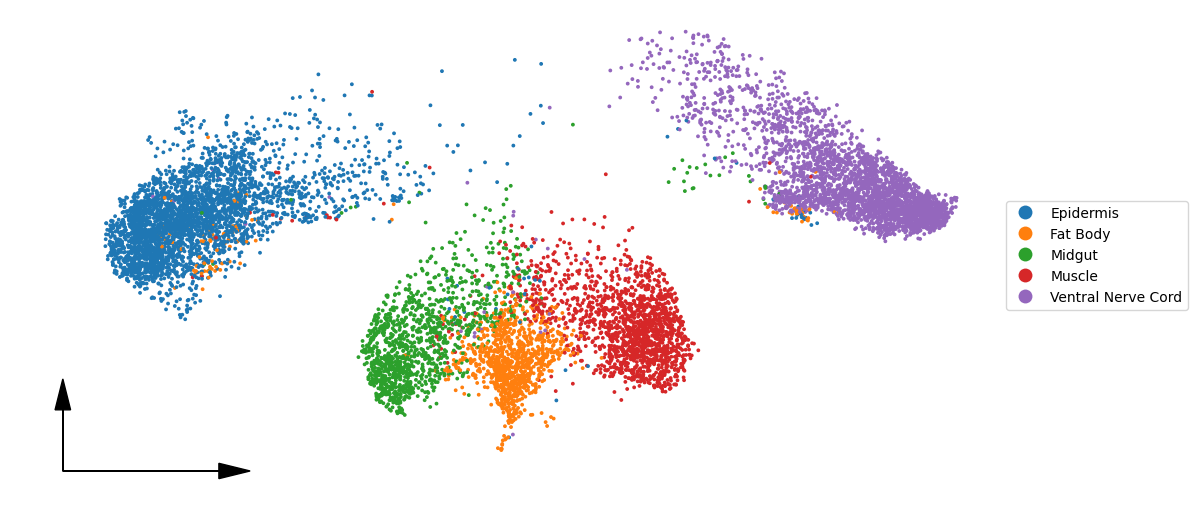

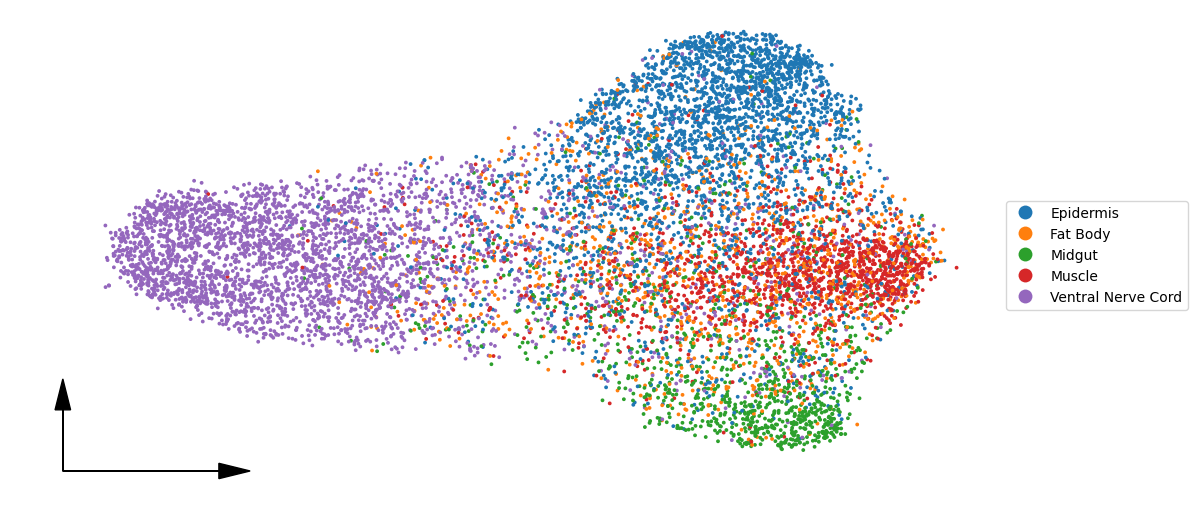

In [7]:
import pandas as pd
for adata in (cttag, mt):
    label_array = adata.obs['label'].to_numpy()

    mask_muscle = label_array == 'Muscle'
    mask_fat_body = label_array == 'Fat Body'
    label_array[mask_muscle+mask_fat_body] = 'Mesoderm'

    #adata.obs['label'] = pd.Categorical(label_array)
    scit.pl.embedding2d(adata, 'X_umap', 'label')

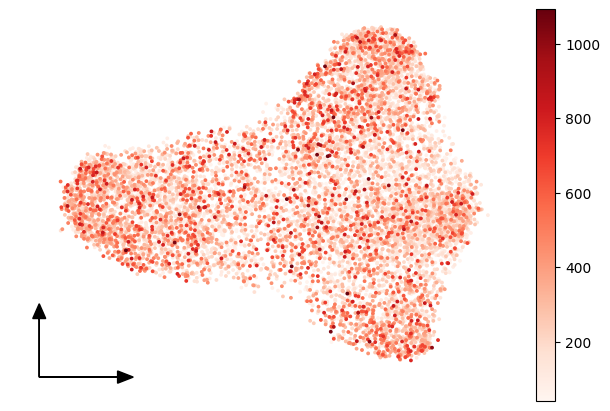

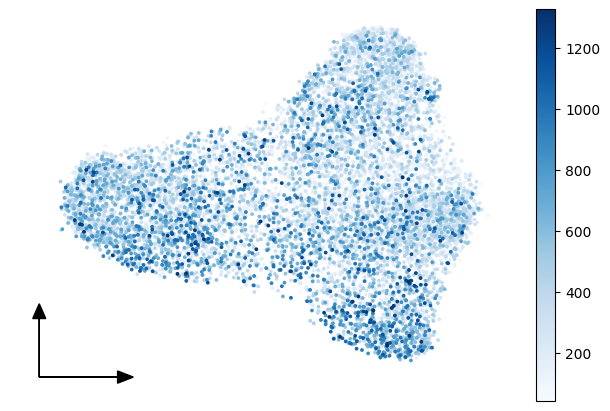

In [8]:
scit.set_defaults(figsize=(6,4))
scit.pl.embedding2d(mt, 'X_umap', 'meth_total_counts', cmap='Reds')
scit.pl.embedding2d(mt, 'X_umap', 'acet_total_counts', cmap='Blues')

In [9]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=False,
    #log_transform=True,
    #normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=False,
    #log_transform=True,
    #normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

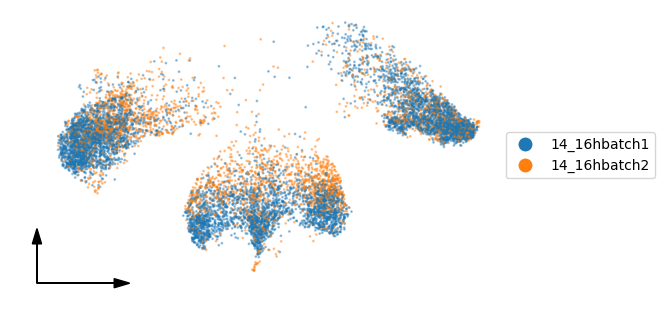

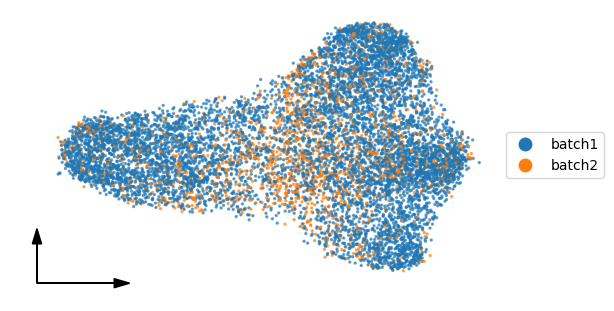

In [8]:
import pandas as pd
scit.set_defaults(figsize=(5,3))
cttag.obs['time_batch'] = pd.Categorical(cttag.obs['timep'].to_numpy() + cttag.obs['batch'].to_numpy())
scit.pl.embedding2d(cttag, 'X_umap', 'time_batch', size=1, alpha=0.4)
scit.pl.embedding2d(mt, 'X_umap', 'batch', size=2, alpha=0.6)

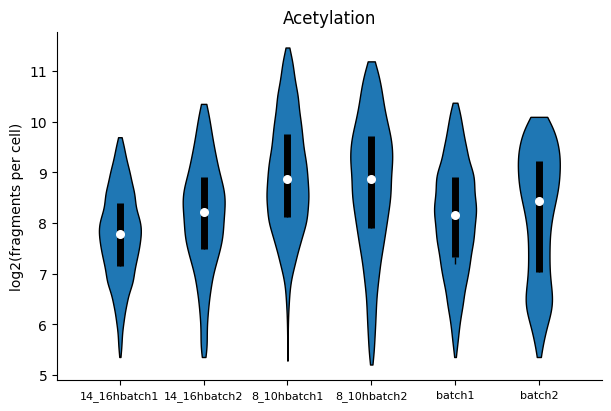

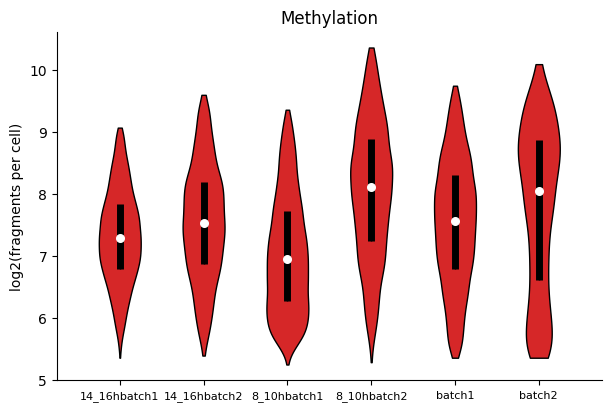

In [7]:
scit.set_defaults(figsize=(6,4))
for l, c, t in [(lc_acet, 'tab:blue', 'Acetylation'), (lc_meth, 'tab:red', 'Methylation')]:
    ddict = scit.tl.membership_summary(cttag, l, 'time_batch', use_cached_mask=False)
    ddict_m = scit.tl.membership_summary(mt, l, 'batch', use_cached_mask=False)
    ddict = ddict | ddict_m
    scit.pl.int.violin([np.log2(d.sum(axis=1).A1) for d in ddict.values()], ddict.keys(), color=c, title=t,
    label_size=8, ylabel='log2(fragments per cell)', show=False).savefig(f'private/newest/figures/violin_{t}.pdf')

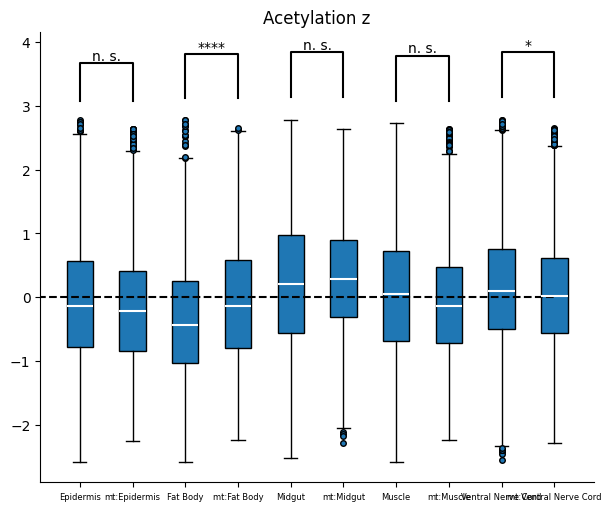

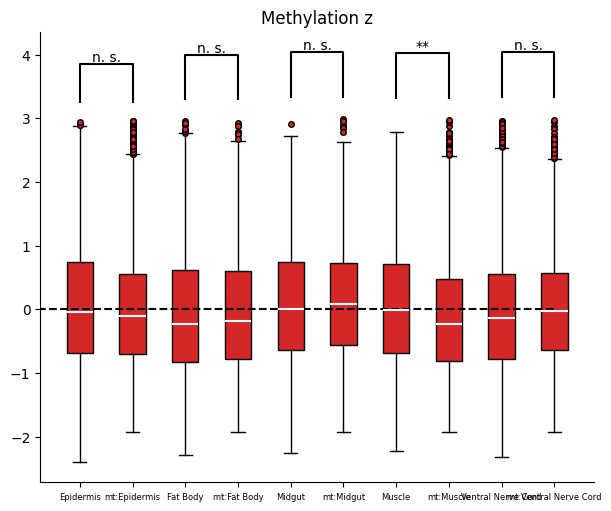

In [13]:
scit.set_defaults(figsize=(6,5))
#ddict = scit.tl.membership_summary(cttag, lc_acet, 'label', use_cached_mask=False) #normalize_per_class_obs_key='time_batch')
#scit.pl.int.violin([np.log2(d.sum(axis=1).A1) for d in ddict.values()], ddict.keys(), color='tab:blue', title="Acetylation")
#
#ddict = scit.tl.membership_summary(cttag, lc_meth, 'label', use_cached_mask=False) #normalize_per_class_obs_key='time_batch')
#scit.pl.int.violin([np.log2(d.sum(axis=1).A1) for d in ddict.values()], ddict.keys(), color='tab:red', title="Methylation")
#
#ddict = scit.tl.membership_summary(mt, lc_acet, 'label', use_cached_mask=False) #normalize_per_class_obs_key='time_batch')
#scit.pl.int.violin([np.log2(d.sum(axis=1).A1) for d in ddict.values()], ddict.keys(), color='tab:blue', title="KD Acetylation")
#
#ddict = scit.tl.membership_summary(mt, lc_meth, 'label', use_cached_mask=False) #normalize_per_class_obs_key='time_batch')
#scit.pl.int.violin([np.log2(d.sum(axis=1).A1) for d in ddict.values()], ddict.keys(), color='tab:red', title="KD Methylation")
def transf(xs, z_trans=True):
        xs = [np.log2(d.sum(axis=1).A1) for d in xs]
        if z_trans:
            xsn = np.concatenate(xs)
            xs = [(d - xsn.mean()) / xsn.std() for d in xs]
        return xs

l_wt = dict(
    use_cached_mask=False,
    normalize_per_class_obs_key='batch'
)
l_mt = dict(
    use_cached_mask=False,
    normalize_per_class_obs_key='batch'
)
import matplotlib.pyplot as plt

for l,n,c,ssk in [(lc_acet, 'Acetylation z', 'blue', 'two-sided'), (lc_meth, 'Methylation z', 'red', 'greater')]:
    ddict = scit.tl.membership_summary(mt, l, 'label', **l_mt)
    val_mt = transf(list(ddict.values()))
    lab_mt = ['mt:'+k for k in ddict.keys()]
    ddict = scit.tl.membership_summary(cttag, l, 'label', **l_wt)
    val_wt = transf(list(ddict.values()))
    lab_wt = [k for k in ddict.keys()]
    stat=scit.tl.statistic_test(
        [val for pair in zip(val_wt, val_mt) for val in pair], 
        [(0,1), (2,3), (4,5), (6,7), (8,9)],
        welch=False,
        test_type='ttest', fdc=True, scipy_stat_kwargs={'alternative': ssk}
    )
    scit.pl.int.boxplot(
          [val for pair in zip(val_wt, val_mt) for val in pair], 
          [val for pair in zip(lab_wt, lab_mt) for val in pair], 
          color=f'tab:{c}', title=n, show=False, label_size=6, stat=stat)
    plt.gcf().axes[0].hlines(0, 0, 10, colors=['black'], linestyles='--')
    plt.gcf().savefig(f'private/newest/figures/cmp_ttest_w-z_{n[:-2]}.pdf')


In [22]:
scit.set_defaults(figsize=(6,5))

lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    log_transform=False,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    log_transform=False,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)


In [ ]:
scit.tl.layer_pick_features(cttag, lc_meth, active_meth)

meth_change_o = scit.tl.likelihood_test_on_adata(
    cttag,
    mt,
    'label',
    lc_meth,
    mean_ranks_normalize=True,
    min_lfc=1
)
meth_change = meth_change_o

Info: Running likelihood test with minimum LFC=1; min_base_mean=None
Info: Running test on 5 features. Group 1 n=3081, group 2 n=3343
Started batch
Finished batch
Info: Running test on 4 features. Group 1 n=2630, group 2 n=2730
Started batch
Finished batch
Info: Running test on 35 features. Group 1 n=1079, group 2 n=1238
Started batch
Finished batch
Info: Running test on 12 features. Group 1 n=3321, group 2 n=3139
Started batch
Finished batch


In [23]:
meth_change = pl.read_csv('private/data/wt_mt_meth_change.csv').filter(pl.col('base_mean') > 0.1)
acet_change = pl.read_csv('private/data/wt_mt_acet_change.csv').filter(pl.col('base_mean') > 0.1)

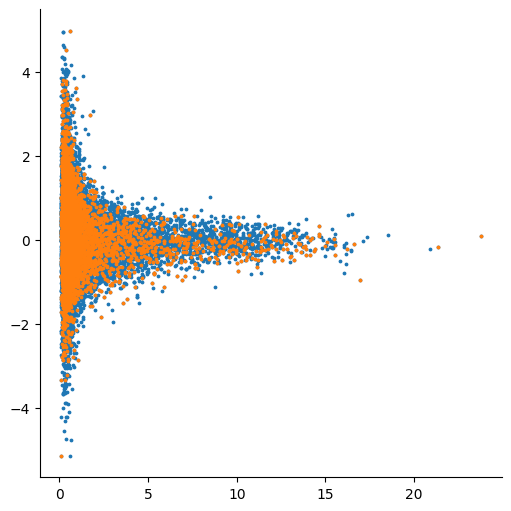

In [32]:
scit.pl.int.scatter(
    [
        np.c_[meth_change['base_mean'].to_numpy(), meth_change['score'].to_numpy()],
        np.c_[meth_change.filter(pl.col('group')=="Muscle")['base_mean'].to_numpy(), meth_change.filter(pl.col('group')=="Muscle")['score'].to_numpy()]
    ], alpha=1
)

In [ ]:
import matplotlib.pyplot as plt
scit.set_defaults(figsize=(5,5))

for uq in meth_change['group'].unique():
    df = meth_change.filter(pl.col('group') == uq)
    scit.pl.volcano_plot(df['pval'].to_numpy(), df['score'].to_numpy(), 
        yminmax=(-1,100), min_lfc=0.25, min_pval=0.001, show=False)
    plt.gcf().savefig(f'private/newest/volcano_mut/{uq}.png')
    plt.close('all')


In [27]:
meth_change.filter((pl.col('group') == 'Muscle') & (pl.col('pval')< 0.001)).sort(pl.col('score'))

pval,score,name,base_mean,group
f64,f64,str,f64,str
0.00091,-1.577227,"""stumps""",1.7489872,"""Muscle"""
0.000005,-1.501535,"""RecQ5""",3.6155922,"""Muscle"""
0.000106,-1.345553,"""CG14488""",2.4963493,"""Muscle"""
0.000532,-1.11919,"""beat-IIIc""",4.253994,"""Muscle"""
0.00001,-1.113462,"""Npc2h""",5.8908215,"""Muscle"""
…,…,…,…,…
0.000157,-0.255553,"""Dfd""",14.37611,"""Muscle"""
0.000083,0.6243679,"""Dbx""",1.8918444,"""Muscle"""
0.000683,1.2459685,"""CG13921""",0.5397718,"""Muscle"""


In [35]:
gn = 'RecQ5'
meth_change.filter(pl.col('name') ==gn)

pval,score,name,base_mean,group
f64,f64,str,f64,str
1.0,-0.091153,"""RecQ5""",1.0325466,"""Ventral Nerve Cord"""
0.5677063,-0.506202,"""RecQ5""",0.832647,"""Midgut"""
0.9864904,-0.607578,"""RecQ5""",2.0477524,"""Epidermis"""
0.8034624,-0.662497,"""RecQ5""",1.6451987,"""Fat Body"""
0.000005,-1.501535,"""RecQ5""",3.6155922,"""Muscle"""


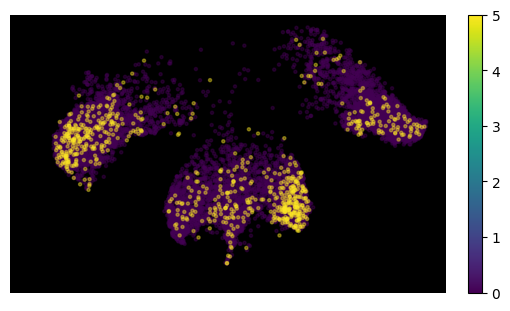

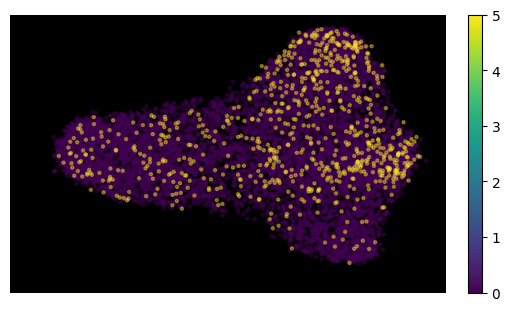

In [36]:
import pandas as pd
scit.set_defaults(figsize=(5,3))
scit.tl.layer_pick_features(cttag, lc_meth, gn)
scit.tl.copy_to_obs(cttag, lc_meth)
scit.tl.copy_to_obs(mt, lc_meth)
scit.pl.embedding2d(cttag, 'X_umap', 'copied_data', size=5, alpha=0.4, black_background=True, vminmax=(0,5))
scit.pl.embedding2d(mt, 'X_umap', 'copied_data', size=5, alpha=0.4, black_background=True, vminmax=(0,5))

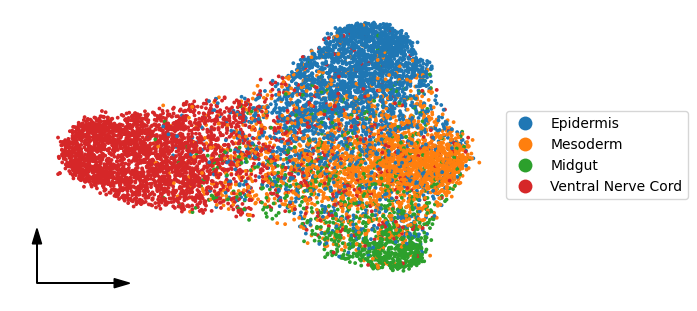

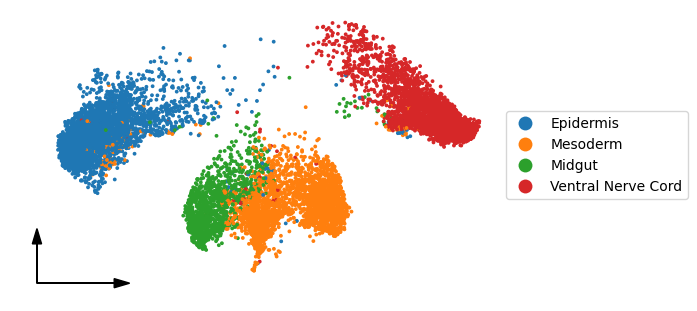

In [86]:

scit.pl.embedding2d(mt, 'X_umap', 'label')
scit.pl.embedding2d(cttag, 'X_umap', 'label')